In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/drive/MyDrive/DATASETS/sample_-_superstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10189,10190,US-2026-143259,12/30/2026,01/03/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,12/30/2026,01/03/2027,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,12/30/2026,01/03/2027,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,12/30/2026,01/03/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
10193,10194,CA-2026-143500,12/30/2026,01/03/2027,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,...,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.2,-0.6048


In [4]:
df.shape

(10194, 21)

In [5]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
df.info

<bound method DataFrame.info of        Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0           1  US-2023-103800  01/03/2023  01/07/2023  Standard Class   
1           2  US-2023-112326  01/04/2023  01/08/2023  Standard Class   
2           3  US-2023-112326  01/04/2023  01/08/2023  Standard Class   
3           4  US-2023-112326  01/04/2023  01/08/2023  Standard Class   
4           5  US-2023-141817  01/05/2023  01/12/2023  Standard Class   
...       ...             ...         ...         ...             ...   
10189   10190  US-2026-143259  12/30/2026  01/03/2027  Standard Class   
10190   10191  US-2026-115427  12/30/2026  01/03/2027  Standard Class   
10191   10192  US-2026-156720  12/30/2026  01/03/2027  Standard Class   
10192   10193  US-2026-143259  12/30/2026  01/03/2027  Standard Class   
10193   10194  CA-2026-143500  12/30/2026  01/03/2027  Standard Class   

      Customer ID      Customer Name      Segment Country/Region  \
0        DP-13000      Darren Powers     Consumer  United States   
1        PO-19195      Phillina Ober  Home Office  United States   
2        PO-19195      Phillina Ober  Home Office  United States   
3        PO-19195      Phillina Ober  Home Office  United States   
4        MB-18085         Mick Brown     Consumer  United States   
...           ...                ...          ...            ...   
10189    PO-18865  Patrick O'Donnell     Consumer  United States   
10190    EB-13975         Erica Bern    Corporate  United States   
10191    JM-15580      Jill Matthias     Consumer  United States   
10192    PO-18865  Patrick O'Donnell     Consumer  United States   
10193    HO-15230        Harry Olson     Consumer         Canada   

                City  ... Postal Code   Region       Product ID  \
0            Houston  ...       77095  Central  OFF-PA-10000174   
1         Naperville  ...       60540  Central  OFF-BI-10004094   
2         Naperville  ...       60540  Central  OFF-LA-10003223   
3         Naperville  ...       60540  Central  OFF-ST-10002743   
4       Philadelphia  ...       19143     East  OFF-AR-10003478   
...              ...  ...         ...      ...              ...   
10189  New York City  ...       10009     East  OFF-BI-10003684   
10190      Fairfield  ...       94533     West  OFF-BI-10004632   
10191       Loveland  ...       80538     West  OFF-FA-10003472   
10192  New York City  ...       10009     East  TEC-PH-10004774   
10193  Charlottetown  ...         C0A     East  OFF-BI-10004040   

              Category Sub-Category  \
0      Office Supplies        Paper   
1      Office Supplies      Binders   
2      Office Supplies       Labels   
3      Office Supplies      Storage   
4      Office Supplies          Art   
...                ...          ...   
10189  Office Supplies      Binders   
10190  Office Supplies      Binders   
10191  Office Supplies    Fasteners   
10192       Technology       Phones   
10193  Office Supplies      Binders   

                                            Product Name    Sales  Quantity  \
0      Message Book, Wirebound, Four 5 1/2" X 4" Form...   16.448         2   
1             GBC Standard Plastic Binding Systems Combs    3.540         2   
2                                              Avery 508   11.784         3   
3                          SAFCO Boltless Steel Shelving  272.736         3   
4      Avery Hi-Liter EverBold Pen Style Fluorescent ...   19.536         3   
...                                                  ...      ...       ...   
10189               Wilson Jones Legal Size Ring Binders   52.776         3   
10190                                 GBC Binding covers   20.720         2   
10191                                Bagged Rubber Bands    3.024         3   
10192                          Gear Head AU3700S Headset   90.930         7   
10193                        Wilson Jones Impact Binders    3.024         3   

       Discount   Profit  
0           0.2   5.5512

<Axes: >

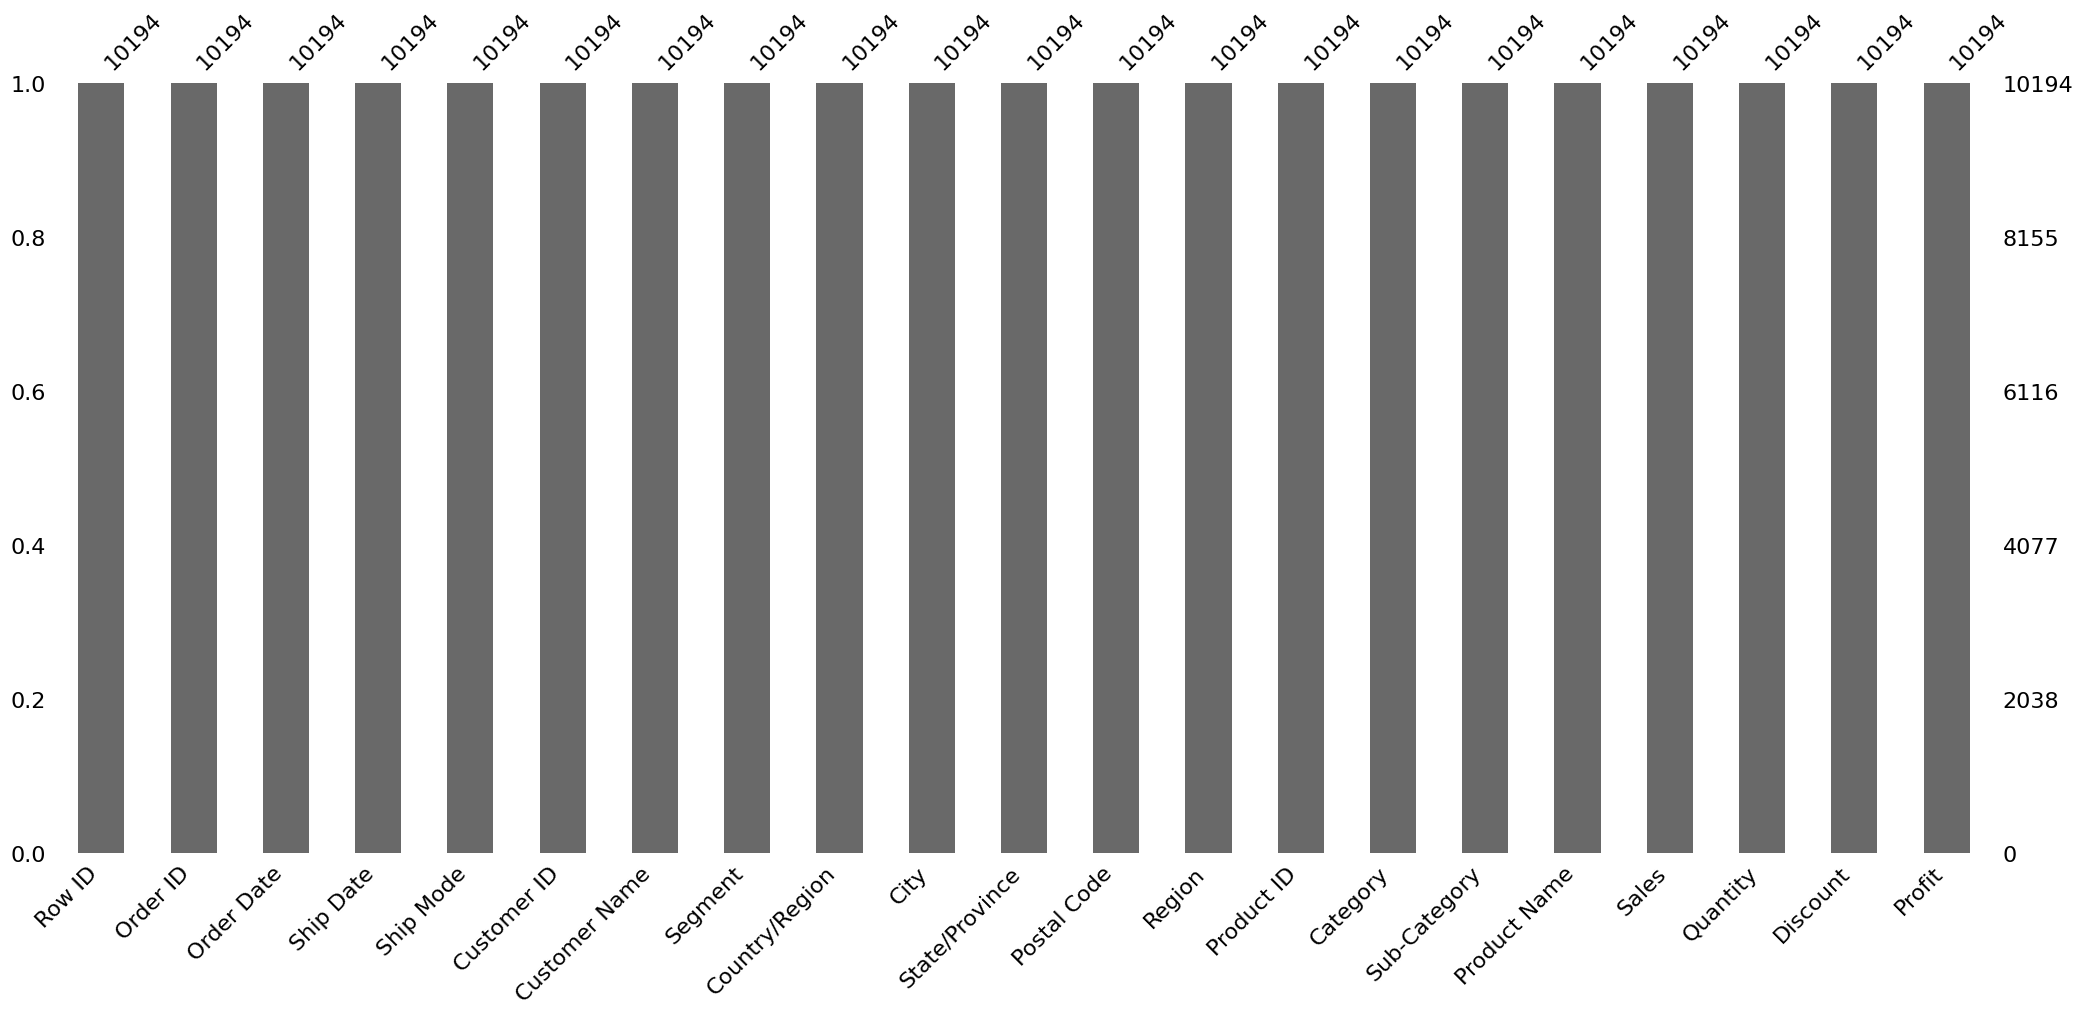

In [7]:
!pip install missingno
import missingno as msno
msno.bar(df)

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

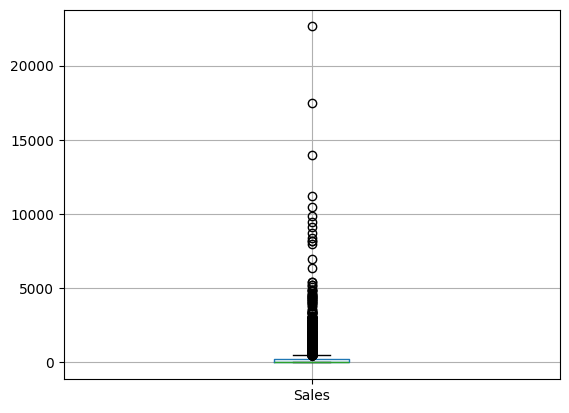

In [13]:
df.boxplot('Sales')

plt.show()

In [45]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
con=['Order ID','Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name','Postal Code'	]
for c in con:
  df[c]=le.fit_transform(df[c])
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,164,4,21,3,230,199,0,1,211,...,418,0,1026,1,12,1080,16.448,2,0.2,5.5512
1,2,287,8,25,3,616,618,2,1,327,...,318,0,804,1,3,707,3.540,2,0.8,-5.4870
2,3,287,8,25,3,616,618,2,1,327,...,318,0,987,1,10,217,11.784,3,0.2,4.2717
3,4,287,8,25,3,616,618,2,1,327,...,318,0,1378,1,14,1363,272.736,3,0.2,-64.7748
4,5,709,11,37,3,494,543,0,1,380,...,37,1,582,1,2,250,19.536,3,0.2,4.8840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,4485,1238,11,3,614,596,0,1,335,...,1,1,784,1,3,1638,52.776,3,0.2,19.7910
10190,10191,3800,1238,11,3,252,264,1,1,150,...,584,3,831,1,3,677,20.720,2,0.2,6.4750
10191,10192,4796,1238,11,3,398,374,0,1,272,...,462,3,934,1,8,283,3.024,3,0.2,-0.6048
10192,10193,4485,1238,11,3,614,596,0,1,335,...,1,1,1850,2,13,730,90.930,7,0.0,2.7279


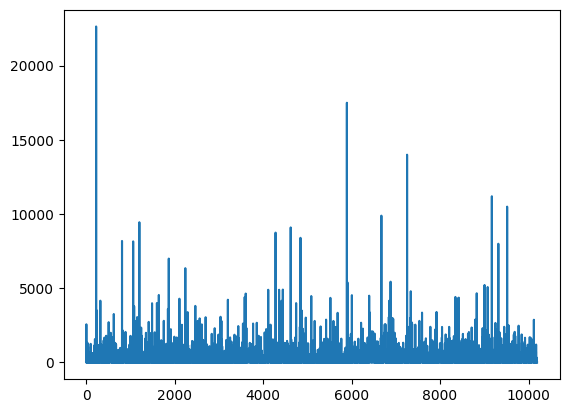

In [17]:
x=df['Sales']
plt.plot(x)

(array([1.0000e+00, 2.0000e+00, 4.0000e+00, 3.4000e+01, 1.0106e+04,
        3.6000e+01, 5.0000e+00, 4.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([-6599.978 , -5099.9826, -3599.9872, -2099.9918,  -599.9964,
          899.999 ,  2399.9944,  3899.9898,  5399.9852,  6899.9806,
         8399.976 ]),
 <BarContainer object of 10 artists>)

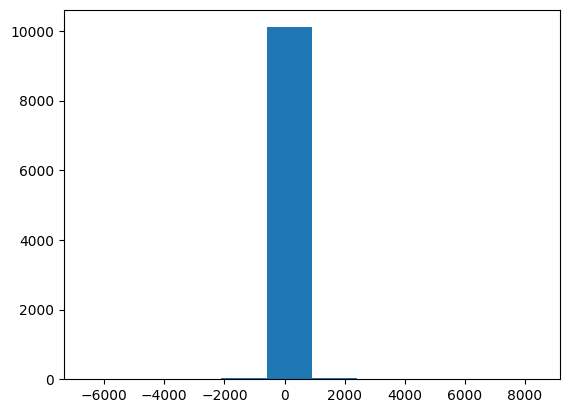

In [19]:
y=df['Profit']
plt.hist(y)

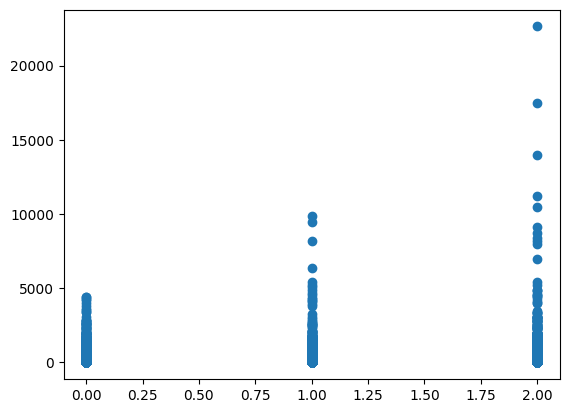

In [20]:
plt.scatter(df['Category'],df['Sales'])

In [27]:
cols=['Sales','Profit','Category','Discount']

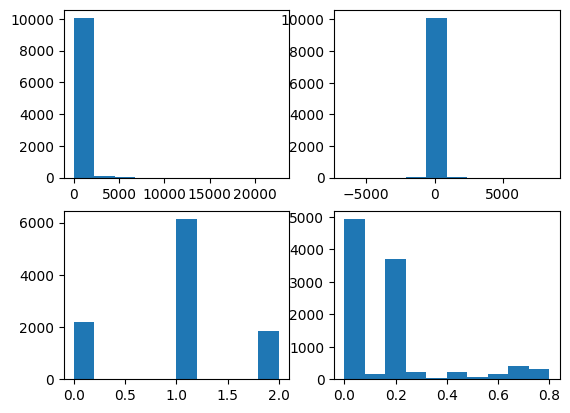

In [28]:
for i in range(len(cols)):
    plt.subplot(2,2,i+1)
    plt.hist(df[cols[i]])

plt.show()

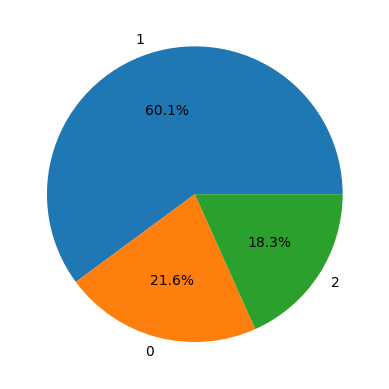

In [31]:
plt.pie(df['Category'].value_counts(),
        labels=df['Category'].value_counts().index,
        autopct='%1.1f%%')

plt.show()

<Axes: ylabel='Sales'>

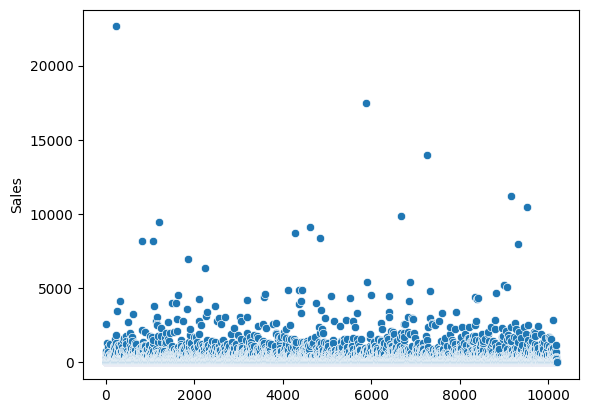

In [32]:
sns.scatterplot(df['Sales'])

<Axes: xlabel='Sales', ylabel='Profit'>

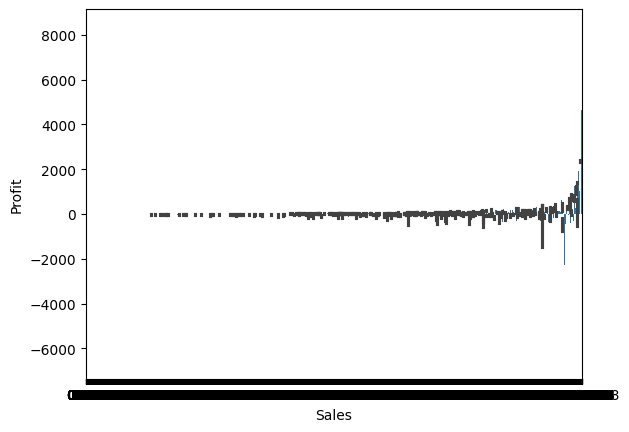

In [35]:
sns.barplot(x='Sales',y='Profit',data=df)

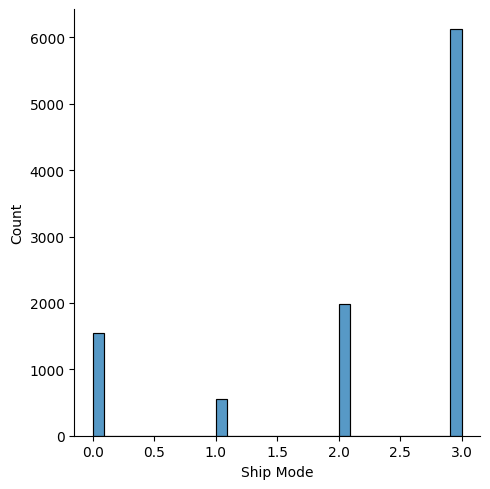

In [36]:
sns.displot(df['Ship Mode'])

/tmp/ipykernel_4265/3976280834.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Ship Mode'])


<Axes: xlabel='Ship Mode', ylabel='Density'>

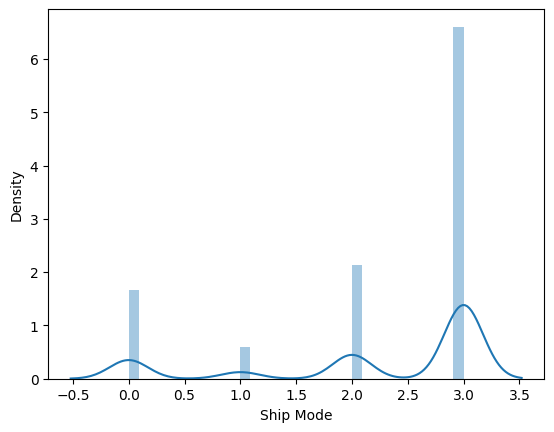

In [37]:
sns.distplot(df['Ship Mode'])

In [ ]:
sns.pairplot(df,hue='Profit')

In [72]:
x = df.drop('Category', axis=1)
y = df['Category']
x_train , x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [73]:
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

Accuracy: 1.0
classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       421
           1       1.00      1.00      1.00      1238
           2       1.00      1.00      1.00       380

    accuracy                           1.00      2039
   macro avg       1.00      1.00      1.00      2039
weighted avg       1.00      1.00      1.00      2039

confusion matrix [[ 421    0    0]
 [   0 1238    0]
 [   0    0  380]]


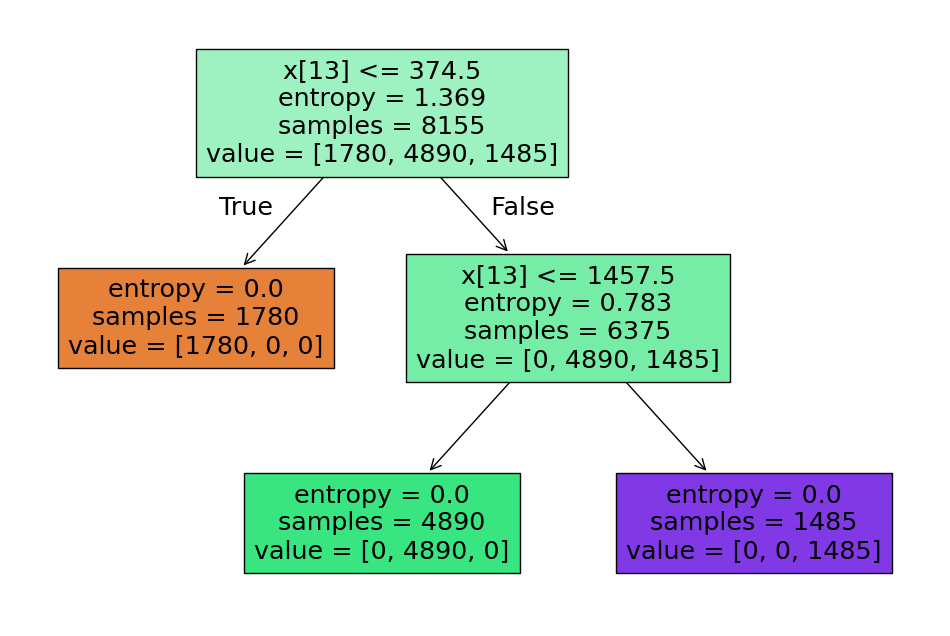

In [74]:
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print( "classification report",classification_report(y_test, y_pred))

print("confusion matrix",confusion_matrix(y_test, y_pred))
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(model, filled=True)
plt.show()

Accuracy: 1.0
confusion matrix [[ 466    0    0]
 [   0 1220    0]
 [   0    0  353]]
classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       466
           1       1.00      1.00      1.00      1220
           2       1.00      1.00      1.00       353

    accuracy                           1.00      2039
   macro avg       1.00      1.00      1.00      2039
weighted avg       1.00      1.00      1.00      2039



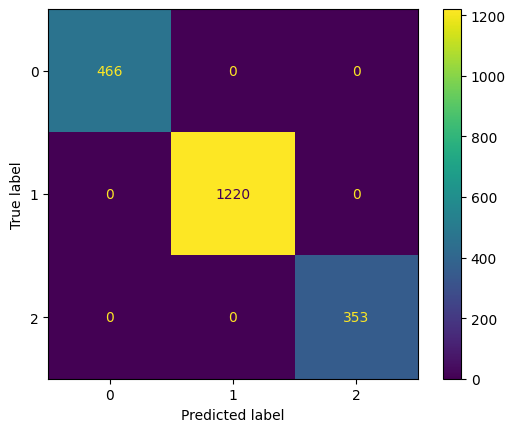

In [71]:
X = df.drop('Category', axis=1)
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print('confusion matrix',confusion_matrix(y_test, y_pred))

print('classification report',classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                              )
disp.plot()

Accuracy: 1.0
confusion matrix [[ 466    0    0]
 [   0 1220    0]
 [   0    0  353]]
classification report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       466
           1       1.00      1.00      1.00      1220
           2       1.00      1.00      1.00       353

    accuracy                           1.00      2039
   macro avg       1.00      1.00      1.00      2039
weighted avg       1.00      1.00      1.00      2039



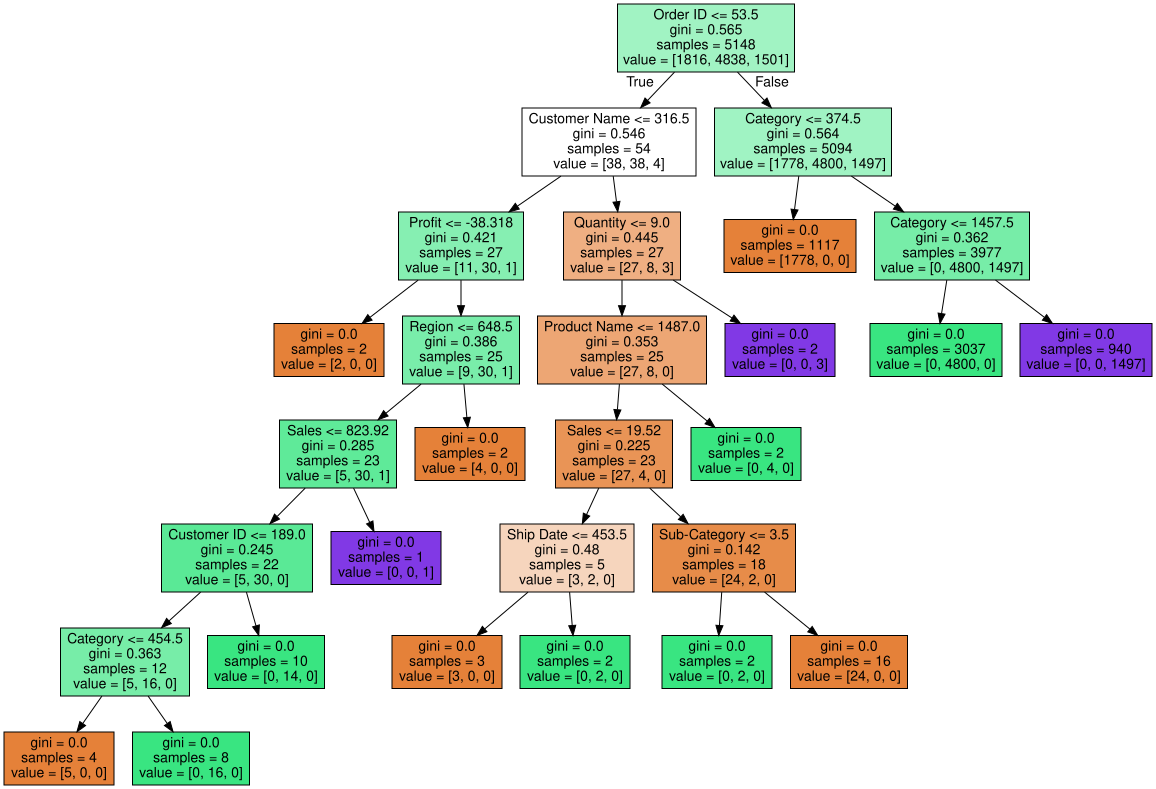

In [70]:
X = df.drop('Category', axis=1)
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print('confusion matrix',confusion_matrix(y_test, y_pred))

print('classification report',classification_report(y_test, y_pred))

import graphviz
from sklearn.tree import export_graphviz
tree = model.estimators_[0]

dot_data = export_graphviz(
    tree,
    feature_names=x.columns,
    filled=True
)

graph = graphviz.Source(dot_data)

graph